# Assignment-04

## A4Q1

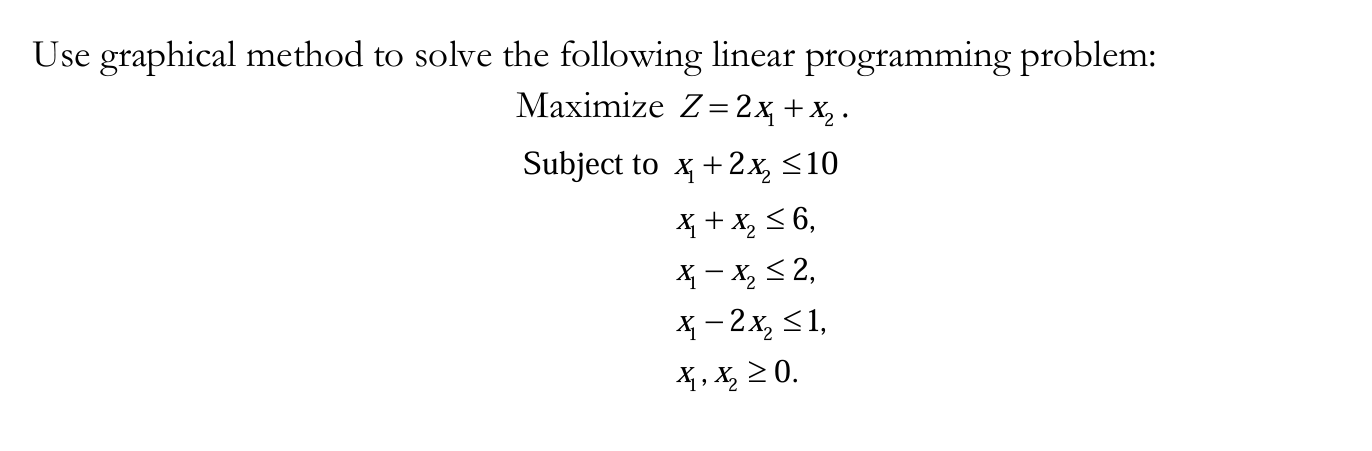

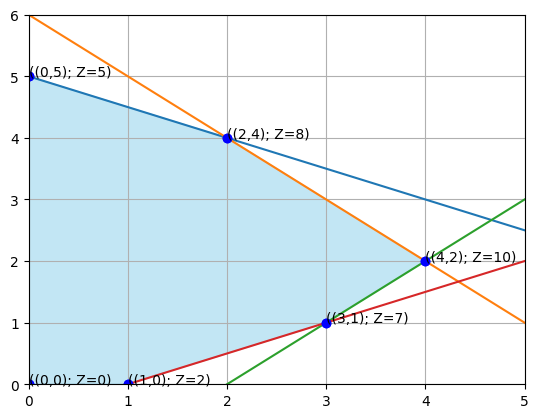

In [4]:
import numpy as np
import matplotlib.pyplot as plt 

# constraints
def c1(x1): return (10-x1)/2
def c2(x1): return (6-x1)
def c3(x1): return -(2-x1)
def c4(x1): return -(1-x1)/2
def Z(x1,x2): return 2*x1 + x2

x=np.linspace(0,10,100)
plt.figure()

plt.plot(x,c1(x))
plt.plot(x,c2(x))
plt.plot(x,c3(x))
plt.plot(x,c4(x))


points=[(0,0), (1,0), (3,1), (4,2), (2,4), (0,5)]
x,y=zip(*points)
plt.fill(x,y, color='skyblue', alpha=0.5)
plt.plot(x,y, 'o', color='blue')

for x, y in points:
    z=str(Z(x,y))
    plt.plot(x,y,'o',color="b")
    plt.text(x,y,f'(({x},{y}); Z={z})')

plt.xlim(0,5)
plt.ylim(0,6)
plt.grid()
plt.show()


## A4Q2

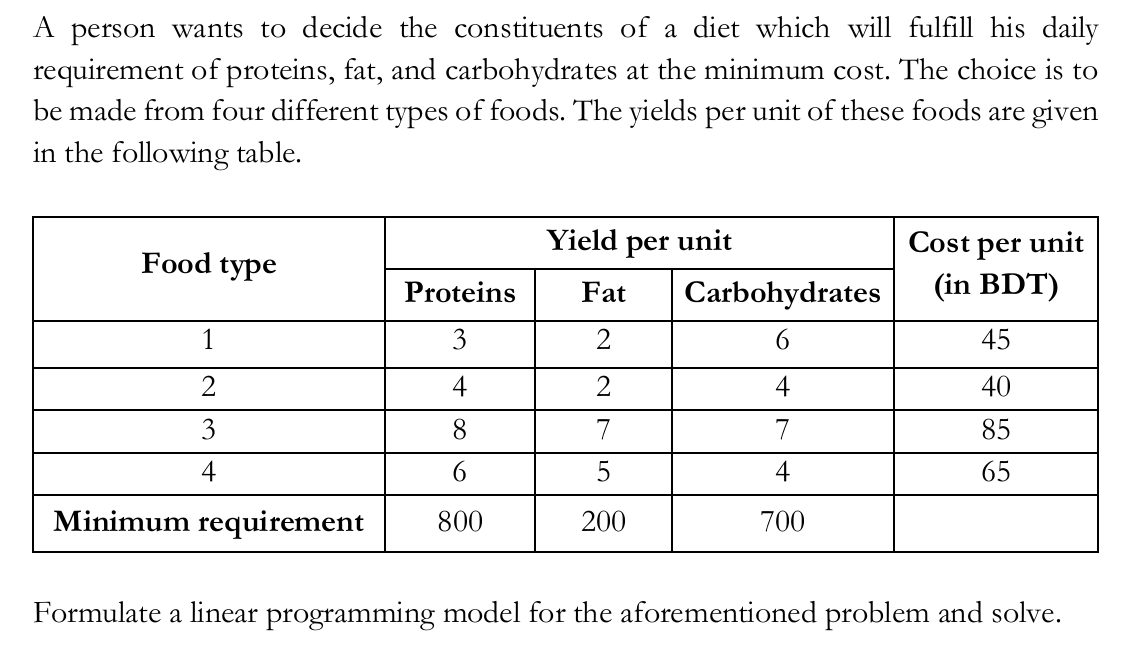

In [5]:
import numpy as np
from scipy.optimize import linprog

A = np.array([
    [3,4,8,6],
    [2,2,7,5],
    [6,4,7,4],
])

req=np.array([800,200,700])
cost=np.array([48,40,85,65])

results=linprog(cost,-A,-req,method="highs")

for i in range(len(cost)):
    print(results.x[i])
    

0.0
200.0
0.0
0.0


## A4Q3

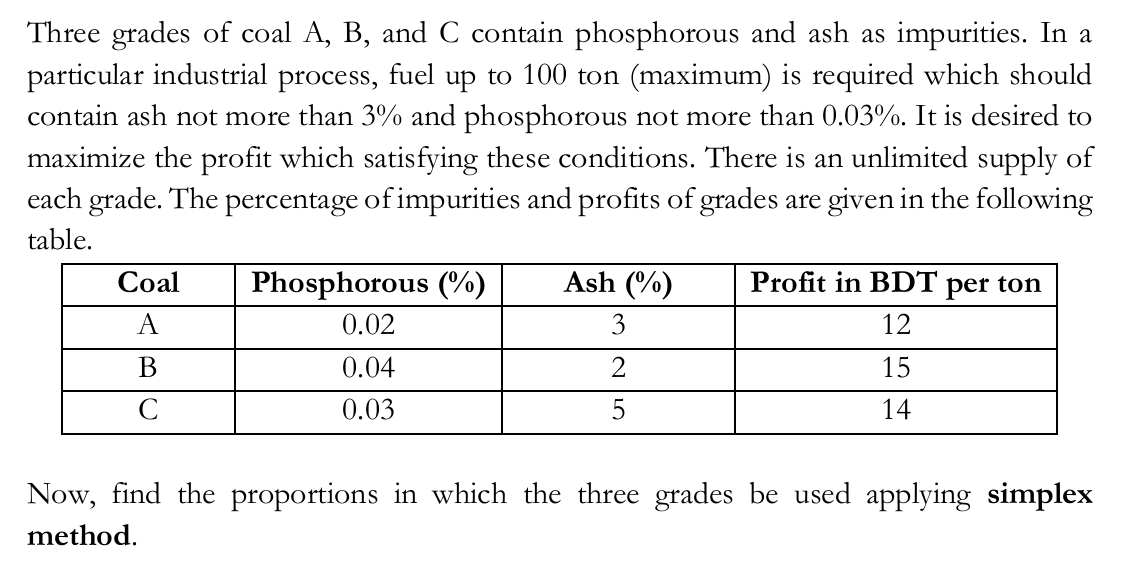

In [9]:
import numpy as np
from scipy.optimize import linprog

A=np.array([
    [0.03, 0.02, 0.05],
    [0.0002, 0.0004, 0.0003]
])

b=np.array([3, 0.03])
cost=np.array([12,15,14])

A_eq=[[1,1,1]]
b_eq=[[100]]

bounds = [(0, None), (0, None), (0, None)]

results=linprog(-cost,A_ub=A,b_ub=b,A_eq=A_eq,b_eq=b_eq,bounds=bounds,method="highs")

for i in range(len(cost)):
    print(results.x[i])

print("Maximum Profit: ", -results.fun)


39.99999999999998
40.0
20.00000000000001
Maximum Profit:  1360.0


## A4Q4

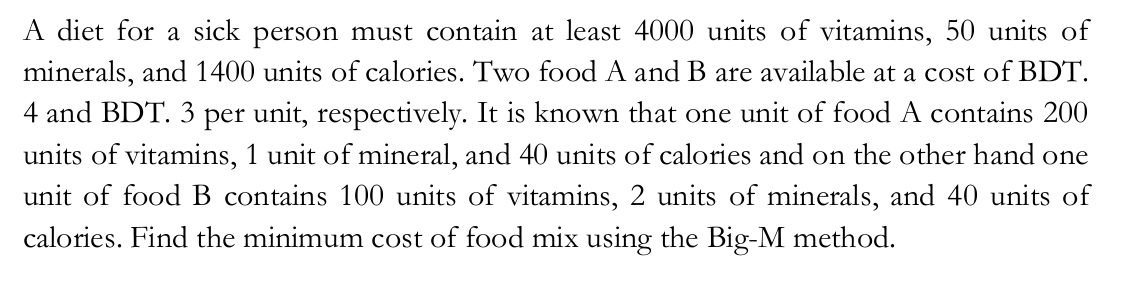

In [8]:
import numpy as np
from scipy.optimize import linprog

M=1e6
c=[4,3,0,0,0,M,M,M]

A=np.array([
    [200,100,-1,0,0,1,0,0],
    [1,2,0,-1,0,0,1,0],
    [40,40,0,0,-1,0,0,1]
])

b=np.array([4000,50,1400])

result=linprog(c,-A,-b,method='simplex')

for i in range(2):
    print(f" food {i+1} : {result.x[i]} unit" )

print(f"optimal cost : {result.fun} tk ")


 food 1 : 5.0 unit
 food 2 : 30.0 unit
optimal cost : 110.0 tk 


C:\Users\Nayeemul Hasan\AppData\Local\Temp\ipykernel_50976\1303180985.py:15: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  result=linprog(c,-A,-b,method='simplex')


## A4Q5

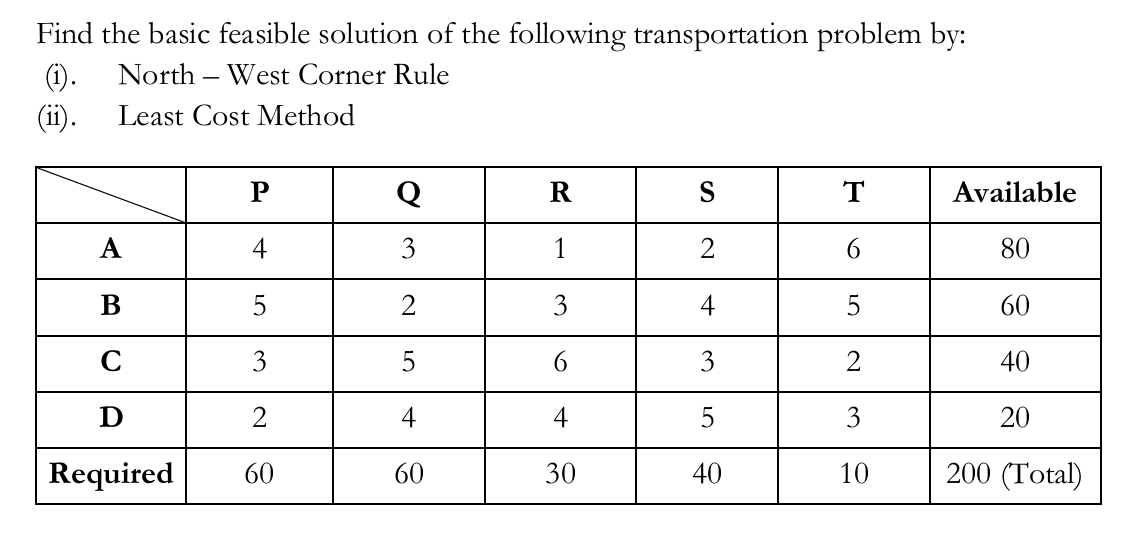

In [11]:
import numpy as np

Cost = np.array([
    [4, 3, 1, 2, 6],
    [5, 2, 3, 4, 5],
    [3, 5, 6, 3, 2],
    [2, 4, 4, 5, 3]
])
Supply = np.array([80, 60, 40, 20])
Demand = np.array([60, 60, 30, 40, 10])

def NorthWest(Cost, Supply, Demand):
    S = Supply.copy()
    D = Demand.copy()
    X = np.zeros_like(Cost, dtype=int)
    i = j = 0
    
    while i < len(S) and j < len(D):
        q = min(S[i], D[j])
        X[i, j] = q
        
        S[i] -= q
        D[j] -= q
        
        if S[i] == 0:
            i += 1
        if D[j] == 0:
            j += 1
    
    return X

print("## North-West Corner Method (NWC)")
NWC_X = NorthWest(Cost, Supply, Demand)
print(NWC_X)
print(f"NWC Total Cost: {(NWC_X * Cost).sum()}")

print("\n" + "-"*40 + "\n")

def LeastCost(Cost, Supply, Demand):
    S = Supply.copy()
    D = Demand.copy()
    C = Cost.copy().astype(float)
    X = np.zeros_like(Cost, dtype=int)
    
    while np.sum(S) > 0 and np.sum(D) > 0:
        min_cost = np.min(C)
        i_all, j_all = np.where(C == min_cost)
        
        i, j = i_all[0], j_all[0]
        
        q = min(S[i], D[j])
        
        X[i, j] = q
        S[i] -= q
        D[j] -= q
        
        if S[i] == 0:
            C[i, :] = 1e6
        if D[j] == 0:
            C[:, j] = 1e6
        if S[i] > 0 and D[j] > 0:
            C[i, j] = 1e6
            
    return X

print("## Least-Cost Method (LCM)")
LCM_X = LeastCost(Cost, Supply, Demand)
print(LCM_X)
print(f"LCM Total Cost: {(LCM_X * Cost).sum()}")

## North-West Corner Method (NWC)
[[60 20  0  0  0]
 [ 0 40 20  0  0]
 [ 0  0 10 30  0]
 [ 0  0  0 10 10]]
NWC Total Cost: 670

----------------------------------------

## Least-Cost Method (LCM)
[[10  0 30 40  0]
 [ 0 60  0  0  0]
 [30  0  0  0 10]
 [20  0  0  0  0]]
LCM Total Cost: 420


## A4Q6

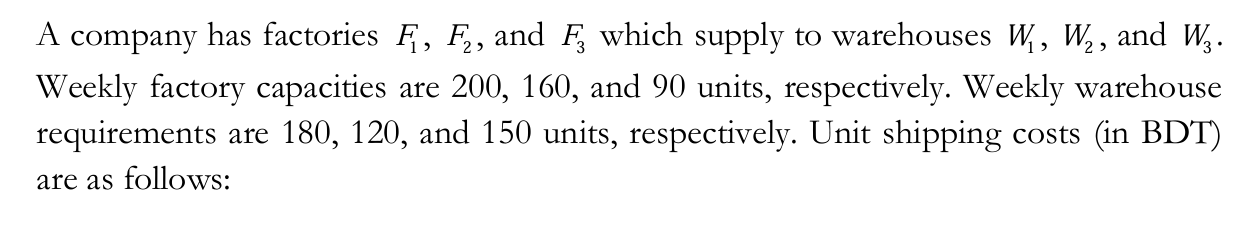
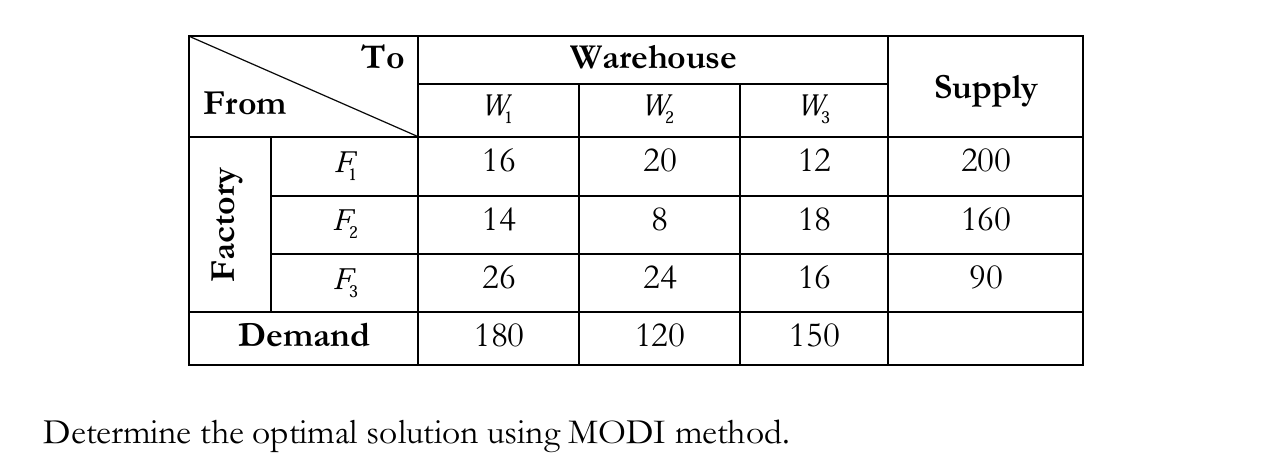

In [13]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog

factories   = ['F1', 'F2', 'F3']
warehouses  = ['W1', 'W2', 'W3']
cost_matrix = np.array([[16, 20, 12],
                        [14,  8, 18],
                        [26, 24, 16]])
cost = cost_matrix.flatten()

supply = [200, 160,  90]
demand = [180, 120, 150]

A_ub, b_ub = [], []

for i in range(3):
    row = np.zeros(9)
    row[i*3:(i+1)*3] = 1
    A_ub.append(row);  b_ub.append(supply[i])

for j in range(3):
    row = np.zeros(9)
    for i in range(3):
        row[i*3 + j] = -1
    A_ub.append(row);  b_ub.append(-demand[j])

results = linprog(cost, A_ub=np.array(A_ub), b_ub=np.array(b_ub), bounds=[(0, None)]*9, method='highs')

alloc = results.x.reshape(3, 3)
df = pd.DataFrame(alloc.astype(int), index=factories, columns=warehouses)

print("Optimal shipment plan (units):")
print(df.to_string())
print(f"\nMinimum total cost: {results.fun:.0f} tk")

Optimal shipment plan (units):
     W1   W2  W3
F1  140    0  60
F2   40  120   0
F3    0    0  90

Minimum total cost: 5920 tk


## A4Q7

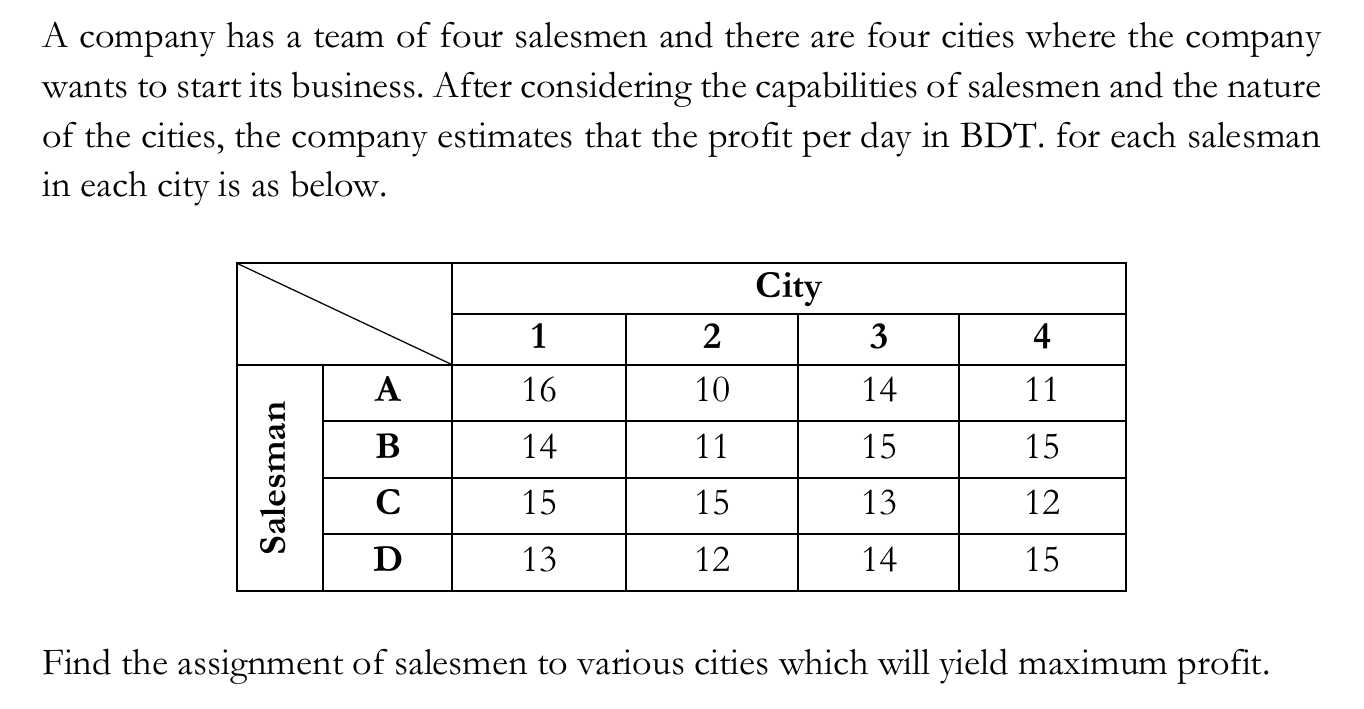

In [22]:
import numpy as np
from scipy.optimize import linear_sum_assignment

profit = np.array([
    [16, 10, 14, 11],
    [14, 11, 15, 15],
    [15, 15, 13, 12],
    [13, 12, 14, 15]
])

cost= - profit

x,y = linear_sum_assignment(cost)

assignment=list(zip("ABCD", (y + 1)))

print(f"assignment: {assignment}")
print(f"profit: {profit[x, y].sum()}")

assignment: [('A', np.int64(1)), ('B', np.int64(3)), ('C', np.int64(2)), ('D', np.int64(4))]
profit: 61


## A4Q8

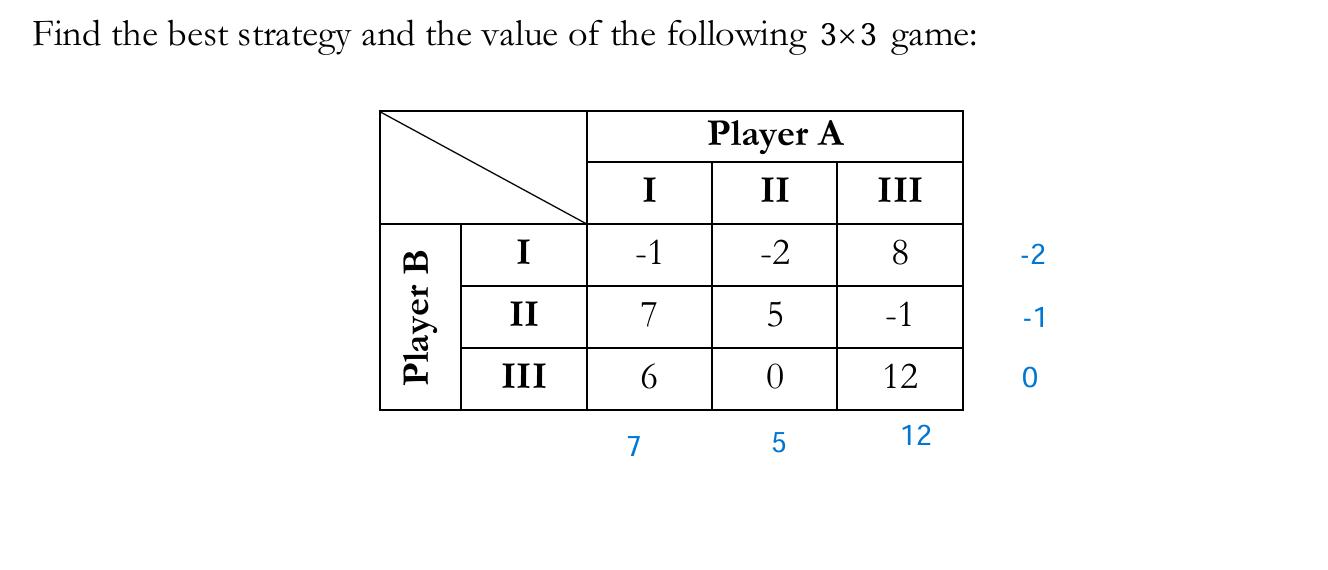

In [23]:
import nashpy as nash
import numpy as np

B = np.array([[-1, -2, 8], [7, 5, -1], [6, 0, 12]])
A= np.transpose(B)
game = nash.Game(A, -A)

for a, b in game.vertex_enumeration():
    print(a.round(4), b.round(4), game[a, b].round(4)) 


[0.5294 0.     0.4706] [ 0.4706  0.5294 -0.    ] [ 3.2353 -3.2353]
